In [1]:
from cherrypick.orchestrator import Orchestrator
from cherrypick.preprocessing import Preprocessor
from cherrypick.anomaly import OutlierPruner
from cherrypick.splits import splitter
from cherrypick.explain import bar_plot, summary_plot, explainer
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, None, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, None, 35, 29],
    "target":     [100, 111, 222, 500, 899, 641, 112, 400, 10000, 80000, 190, 133, 112, 41, 1]
    # "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 2, 1]
})

In [10]:
df.isna().sum()

feature_1    0
feature_2    0
feature_3    1
feature_4    0
feature_5    1
target       0
dtype: int64

## Oulier removal

In [11]:
df


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,12,100,1.0,5,10.0,100
1,45,200,NaN,3,20.0,111
2,23,150,1.0,6,15.0,222
3,67,300,0.0,2,25.0,500
4,34,250,1.0,7,18.0,899
5,89,400,0.0,1,30.0,641
6,54,350,1.0,8,28.0,112
7,21,120,0.0,4,12.0,400
8,76,370,1.0,9,27.0,10000
9,38,220,1.0,5,19.0,80000


In [10]:
outlier = OutlierPruner(df = df, col='target', method='isoforest')
df = outlier.remove_outlier()


In [11]:
df

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,12,100,1.0,5,10.000000,100
1,45,200,1.0,3,20.000000,111
2,23,150,1.0,6,15.000000,222
3,67,300,0.0,2,25.000000,500
4,34,250,1.0,7,18.000000,899
5,89,400,0.0,1,30.000000,641
6,54,350,1.0,8,28.000000,112
7,21,120,0.0,4,12.000000,400
10,49,260,0.0,6,22.000000,190
11,62,310,1.0,7,24.000000,133


In [3]:
process = Preprocessor(df = df)
process.fill_null(type='mean', columns='feature_5')
process.fill_null(type='mode', columns='feature_3')

# df['feature_3'] = df['feature_3'].fillna(df['feature_3'].mode()[0])
df['feature_3'].isna().sum()

0

['feature_2', 'feature_5']

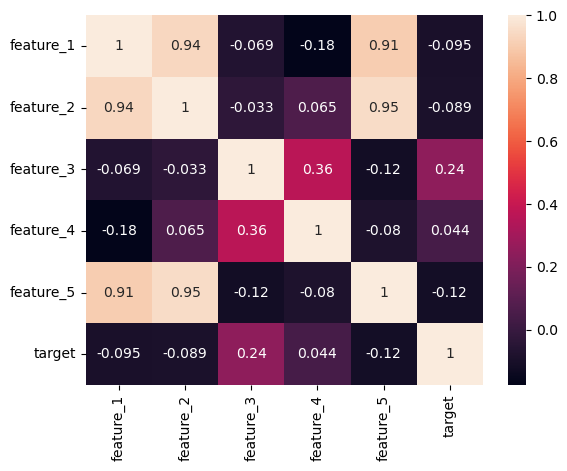

In [7]:
process.collinear(method='pearson', show=True, threshold=0.85)

In [8]:
train, test = splitter(df=df, target='target', test_size=0.25)

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (9, 5)
Independent Feature = (9,)
Test dataset :

Dependent feature = (3, 5)
Independent Feature = (3,)


In [ ]:
cherry = Orchestrator(
    
    problem_statement='regression',
    focus_regressor='rmse',
    file_dir='model',
    train = train,
    test = test

)

In [10]:
cherry.orchestrate()

-------------Demorgraphics-------------
Best Model : SVR
SVR Accuracy(R2 SCore) : -11.80465485947783
SVR RMSE : 111.03810107457855
---------------------------------------


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [11]:
cherry.critique()

With Relative Overfitting Gap = 0.17909217960223803, high chances of data leakage or dataset is too simple


In [14]:
model = cherry.topkmodel(access_estimator = 5)

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════╤════════════════════╤═══════════════════╤════════════════════╤═══════════════════╗ │
│ ║ Rank │     estimator      │      accuracy      │        mse        │        mae         │       rmse        ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥇1  │       SVR()        │ -11.80465485947783 │ 12329.4598902483… │ 106.6633498948806  │ 111.038101074578… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥈2  │ KNeighborsRegress… │ -32.93993537964459 │ 32680.38666666667 │       173.4        │ 180.777174075342… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥉3  │ LinearRegression() │ -67.31680394721873 │ 65781.49144517751 │ 242.35195688789364 │ 256.479027300825… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  4   │ AdaBoostRegressor… │ -79.19236095084237 │ 77216.33333333333 │ 219.66666666666666 │ 277.878270710995… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  5   │ RandomForestRegre… │ -91.23506421647816 │ 88812.11849999998 │ 279.72999999999996 │ 298.013621332985… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  6   │ GradientBoostingR… │ -127.690965733312… │ 123915.101004987… │ 286.67540468607984 │ 352.015768119821… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  7   │ DecisionTreeRegre… │ -156.8873759519963 │     152028.0      │       326.0        │ 389.9076813811187 ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  8   │ XGBRegressor(base… │ -157.295059204101… │   152420.546875   │ 328.4102478027344  │ 390.410741239274… ║ │
│ ║      │   booster=None,    │                    │                   │                    │                   ║ │
│ ║      │  callbacks=None,   │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │ colsample_bynode=… │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │    device=None,    │                    │                   │                    │                   ║ │
│ ║      │ early_stopping_ro… │                    │                   │                    │                   ║ │
│ ║      │              enab… │                    │                   │                    │                   ║ │
│ ║      │ eval_metric=None,  │                    │                   │                    │                   ║ │
│ ║      │ feature_types=Non… │                    │                   │                    │                   ║ │
│ ║      │              feat… │                    │                   │                    │                   ║ │
│ ║      │    gamma=None,     │                    │                   │                    │                   ║ │
│ ║      │ grow_policy=None,  │                    │                   │                    │                   ║ │
│ ║      │              impo… │                    │                   │                    │                   ║ │
│ ║      │ interaction_const… │                    │       

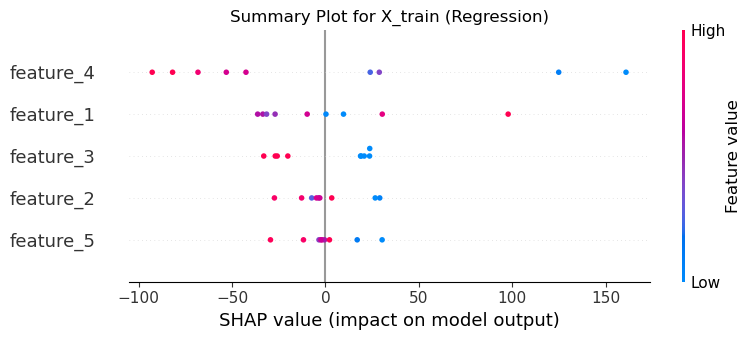

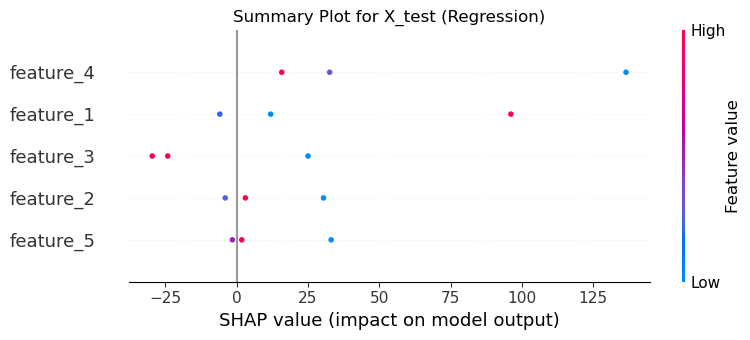

In [15]:
cherry.auto_explain(model=model)

In [2]:
import pandas as pd
df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    # "target":     [100, 111, 222, 500, 899, 641, 112, 400, 10000, 80000, 190, 133, 112, 41, 1]
    "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 0]
})

train, test = splitter(df= df ,target='target', test_size=0.24)
cherry = Orchestrator(
    problem_statement='classification',
    focus_classifier='precision',
    train=train,
    test=test,
    file_dir='model'
)
model = cherry.orchestrate()
# model = cherry.topkmodel(access_estimator=1)
model

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (11, 5)
Independent Feature = (11,)
Test dataset :

Dependent feature = (4, 5)
Independent Feature = (4,)
-------------Demographics-------------
Best Model : RandomForestClassifier(precision)
RandomForestClassifier Accuracy : 0.5
RandomForestClassifier Precision : 1.0
RandomForestClassifier Recall : 0.5
RandomForestClassifier f1score : 0.625
---------------------------------------


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
impact, shap_values = explainer(model=model, impact_type='all', data=train[0])

In [4]:
shap_values

.values =
array([[[-0.12121212, -0.16450216,  0.28571429],
        [-0.2965368 , -0.05411255,  0.35064935],
        [ 0.05411255, -0.05411255,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.75757576, -0.25757576, -0.5       ],
        [-0.06060606, -0.07575758,  0.13636364],
        [-0.06060606,  0.06060606,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

  

In [9]:
import shap
explainer = shap.TreeExplainer(model, train[0])
classk = explainer(test[0]).values[:,:, 0]
classk

array([[-0.95549861,  0.06698868, -1.17625088,  0.00397826, -0.0133825 ],
       [ 0.90003752, -0.00985066, -1.19324987,  0.04640195, -0.02676499],
       [ 0.92773681,  0.06698868, -1.11894529,  0.00397826, -0.0133825 ],
       [ 0.91788085, -0.06263095, -1.16105123, -0.04034143,  0.05352999]])

In [ ]:
for i in range(n_features):
    for j in range(n_classes):
        classk = explainer(test[0]).values[i, : , j]
        print(classk)


[-0.95549861  0.06698868 -1.17625088  0.00397826 -0.0133825 ]
[ 0.0477624  -0.00405882  0.08312536 -0.6681663   0.        ]
[-0.78242359 -0.84481495 -0.15839999  0.46038245  0.05542702]
[ 0.90003752 -0.00985066 -1.19324987  0.04640195 -0.02676499]
[-0.08358421 -0.00405882  0.08312536  1.07267726  0.        ]
[ 0.01258131 -0.95753186 -0.15839999 -1.08178875  0.11085403]
[ 0.92773681  0.06698868 -1.11894529  0.00397826 -0.0133825 ]
[ 0.0477624  -0.00405882  0.08312536 -0.6681663   0.        ]
[-0.78242359 -0.84481495 -0.15839999  0.46038245  0.05542702]
[ 0.91788085 -0.06263095 -1.16105123 -0.04034143  0.05352999]
[-0.08358421  0.00710294  0.08312536 -0.6681663   0.        ]
[ 0.70556638  2.37310178 -0.06335999  0.68823789 -0.22170807]


In [66]:
explainer(test[0]).values[1, :, 2]

array([ 0.01258131, -0.95753186, -0.15839999, -1.08178875,  0.11085403])

In [17]:
val = explainer(test[0]).values
val

array([[[-0.95549861,  0.0477624 , -0.78242359],
        [ 0.06698868, -0.00405882, -0.84481495],
        [-1.17625088,  0.08312536, -0.15839999],
        [ 0.00397826, -0.6681663 ,  0.46038245],
        [-0.0133825 ,  0.        ,  0.05542702]],

       [[ 0.90003752, -0.08358421,  0.01258131],
        [-0.00985066, -0.00405882, -0.95753186],
        [-1.19324987,  0.08312536, -0.15839999],
        [ 0.04640195,  1.07267726, -1.08178875],
        [-0.02676499,  0.        ,  0.11085403]],

       [[ 0.92773681,  0.0477624 , -0.78242359],
        [ 0.06698868, -0.00405882, -0.84481495],
        [-1.11894529,  0.08312536, -0.15839999],
        [ 0.00397826, -0.6681663 ,  0.46038245],
        [-0.0133825 ,  0.        ,  0.05542702]],

       [[ 0.91788085, -0.08358421,  0.70556638],
        [-0.06263095,  0.00710294,  2.37310178],
        [-1.16105123,  0.08312536, -0.06335999],
        [-0.04034143, -0.6681663 ,  0.68823789],
        [ 0.05352999,  0.        , -0.22170807]]])

In [1]:
import numpy as np

In [ ]:
vals = np.abs(val).mean(axis = (0, 2))


1

In [37]:
val

array([[[-0.95549861,  0.0477624 , -0.78242359],
        [ 0.06698868, -0.00405882, -0.84481495],
        [-1.17625088,  0.08312536, -0.15839999],
        [ 0.00397826, -0.6681663 ,  0.46038245],
        [-0.0133825 ,  0.        ,  0.05542702]],

       [[ 0.90003752, -0.08358421,  0.01258131],
        [-0.00985066, -0.00405882, -0.95753186],
        [-1.19324987,  0.08312536, -0.15839999],
        [ 0.04640195,  1.07267726, -1.08178875],
        [-0.02676499,  0.        ,  0.11085403]],

       [[ 0.92773681,  0.0477624 , -0.78242359],
        [ 0.06698868, -0.00405882, -0.84481495],
        [-1.11894529,  0.08312536, -0.15839999],
        [ 0.00397826, -0.6681663 ,  0.46038245],
        [-0.0133825 ,  0.        ,  0.05542702]],

       [[ 0.91788085, -0.08358421,  0.70556638],
        [-0.06263095,  0.00710294,  2.37310178],
        [-1.16105123,  0.08312536, -0.06335999],
        [-0.04034143, -0.6681663 ,  0.68823789],
        [ 0.05352999,  0.        , -0.22170807]]])

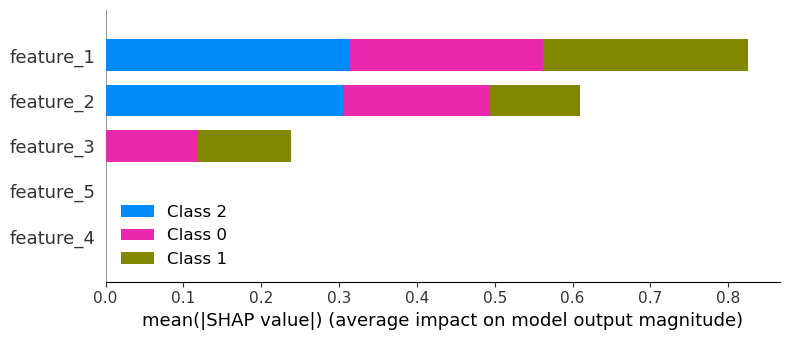

In [5]:
summary_plot(data=test[0])

In [23]:
from cherrypick.explain import explainer
res, exp = explainer(data=train[0], impact_type='all', model=model)

In [24]:
exp

.values =
array([[[-0.12121212, -0.16450216,  0.28571429],
        [-0.2965368 , -0.05411255,  0.35064935],
        [ 0.05411255, -0.05411255,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.75757576, -0.25757576, -0.5       ],
        [-0.06060606, -0.07575758,  0.13636364],
        [-0.06060606,  0.06060606,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

  

In [25]:
shap_values

.values =
array([[[-0.12121212, -0.16450216,  0.28571429],
        [-0.2965368 , -0.05411255,  0.35064935],
        [ 0.05411255, -0.05411255,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.75757576, -0.25757576, -0.5       ],
        [-0.06060606, -0.07575758,  0.13636364],
        [-0.06060606,  0.06060606,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

  

In [26]:
res = res.sort_values(by='Features')
res

,Features,Overall_Impact
0,feature_1,0.275045
1,feature_2,0.203070
2,feature_3,0.079321
3,feature_4,0.000000
4,feature_5,0.000000


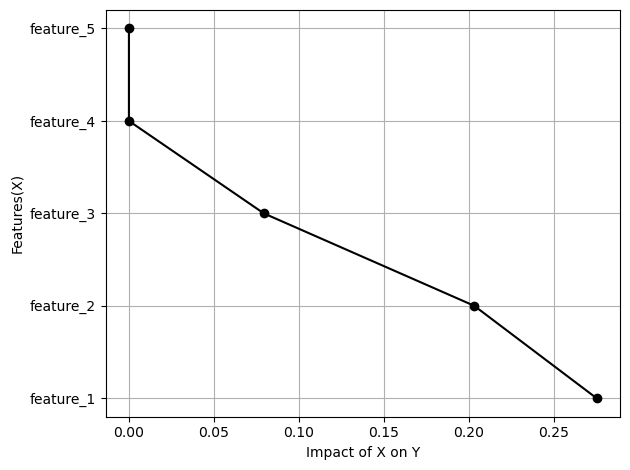

In [27]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.plot(res['Overall_Impact'] , res["Features"], marker='o', color='black')
plt.xlabel("Impact of X on Y")
plt.ylabel("Features(X)")
plt.grid()
plt.tight_layout()

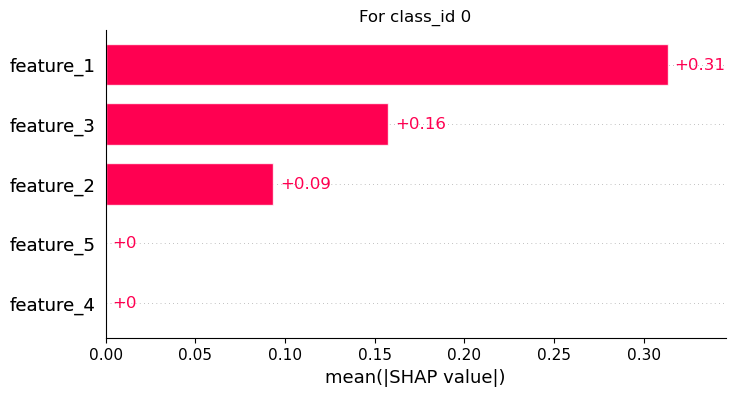

<Figure size 640x480 with 0 Axes>

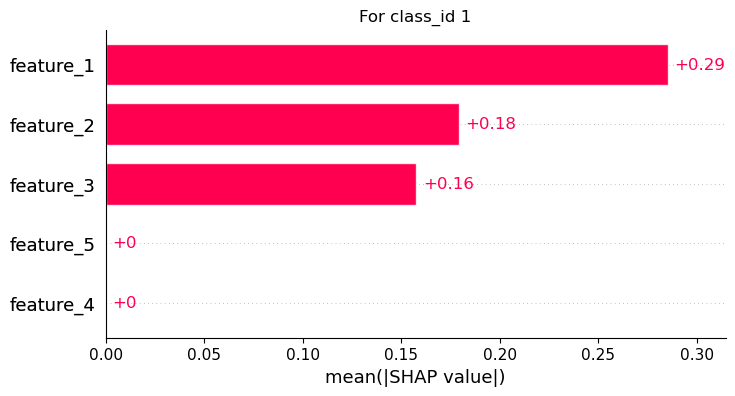

<Figure size 640x480 with 0 Axes>

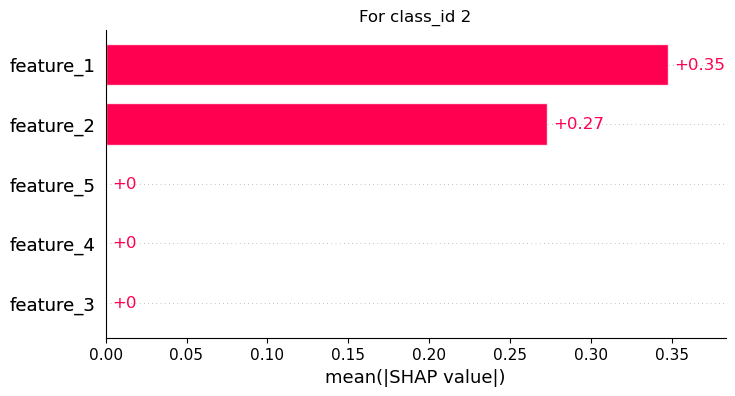

<Figure size 640x480 with 0 Axes>

In [9]:
bar_plot(n_classes=3)

In [10]:
len(train[1].unique())

3

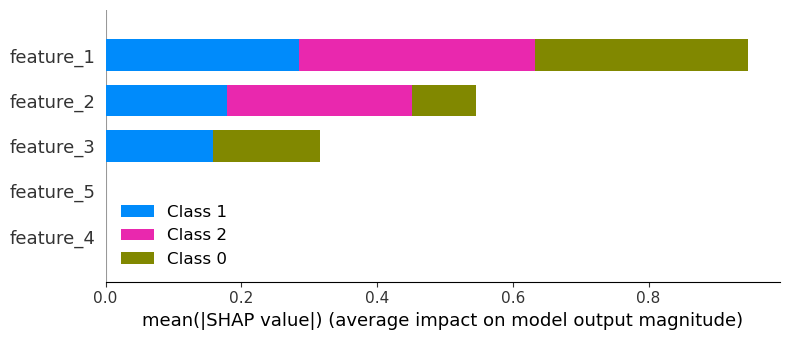

In [11]:
summary_plot(data=train[0])

In [12]:
shap_values

.values =
array([[[-0.12121212, -0.16450216,  0.28571429],
        [-0.2965368 , -0.05411255,  0.35064935],
        [ 0.05411255, -0.05411255,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.75757576, -0.25757576, -0.5       ],
        [-0.06060606, -0.07575758,  0.13636364],
        [-0.06060606,  0.06060606,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[-0.14718615, -0.13852814,  0.28571429],
        [-0.10822511, -0.24242424,  0.35064935],
        [-0.10822511,  0.10822511,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

  

ImportError: cannot import name 'shap_val' from 'cherrypick.explain' (c:\MorphGent\cherrypick\explain.py)

In [31]:
type(model)

sklearn.ensemble._forest.RandomForestClassifier